In [ ]:
import sys
sys.path.append('/content/drive/My Drive/Colab Notebooks')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import time

In [ ]:
#Connect to Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import os
from tensorflow.keras.preprocessing.image import load_img
import random
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, UpSampling2D, MaxPooling2D, Dropout, concatenate, BatchNormalization, Dense, Flatten
from tensorflow.keras.optimizers import Adam

from google.colab.patches import cv2_imshow
import glob
from random import randint

In [ ]:
GDRIVE_PATH = '/content/drive/MyDrive/'

%ls

drive/  sample_data/


In [ ]:
data_train = "Meibomian/Image/"
#data_test = "Tiara/Skripsi/Nonclahe/Dataset/Image test/"

anotasi_train = "Meibomian/Annotasi/"
#anotasi_test = "Tiara/Skripsi/Nonclahe/Dataset/Annotasi test/"

In [ ]:
data_train_file = os.listdir(os.path.join(GDRIVE_PATH, data_train))
#data_test_file = os.listdir(os.path.join(GDRIVE_PATH, data_test))

anotasi_train_file = os.listdir(os.path.join(GDRIVE_PATH, anotasi_train))
#anotasi_test_file = os.listdir(os.path.join(GDRIVE_PATH, anotasi_test))

In [ ]:
print(data_train_file)
print("\n")
print(anotasi_train_file)

['KR_UL33.png', 'KR_UL8.png', 'KR_UL34.png', 'KR_UL35.png', 'KR_UL30.png', 'KR_UL26.png', 'KR_UL13.png', 'KR_UL20.png', 'KR_UL29.png', 'KR_UL31.png', 'KR_UL2.png', 'KR_UL22.png', 'KR_UL24.png', 'KR_UL16.png', 'KR_LL35.png', 'KR_UL23.png', 'KR_UL3.png', 'KR_UL14.png', 'KR_UL25.png', 'KR_UL1.png', 'KR_UL32.png', 'KR_LL16.png', 'KR_UL11.png', 'KR_UL10.png', 'KR_UL19.png', 'KR_LL33.png', 'KR_UL7.png', 'KR_LL34.png', 'KR_UL6.png', 'KR_UL27.png', 'KR_UL5.png', 'KR_LL18.png', 'KR_LL25.png', 'KR_LL29.png', 'KR_LL17.png', 'KR_LL31.png', 'KR_LL32.png', 'KR_UL18.png', 'KR_LL24.png', 'KR_UL28.png', 'KR_UL15.png', 'KR_UL17.png', 'KR_UL4.png', 'KR_LL20.png', 'KR_LL1.png', 'KR_LL23.png', 'KR_LL27.png', 'KR_LL7.png', 'KR_LL22.png', 'KR_LL19.png', 'KR_LL10.png', 'KR_LL8.png', 'KR_LL26.png', 'KR_LL30.png', 'KR_UL12.png', 'KR_LL14.png', 'KR_LL4.png', 'KR_LL3.png', 'KN_UL33.png', 'KR_LL28.png', 'KR_UL9.png', 'KR_LL15.png', 'KN_UL34.png', 'KR_LL21.png', 'KR_LL11.png', 'KR_LL2.png', 'KR_LL12.png', 'KN_UL31.

In [ ]:
def preprocess_data(filename, dir_x, dir_y, SHAPE = 256):
  image_x = cv2.imread(dir_x + filename, 0)
  image_y = cv2.imread(dir_y + filename, 0)

  #reshaping image to 256x256
  image_x = cv2.resize(image_x, (SHAPE, SHAPE), interpolation=cv2.INTER_NEAREST)
  image_y = cv2.resize(image_y, (SHAPE, SHAPE), interpolation=cv2.INTER_NEAREST)
  return image_x, image_y

In [ ]:
data_train_arr = []
anotasi_train_arr = []
#data_test_arr = []
#anotasi_test_arr = []

for filename in data_train_file:
  img_x, img_y = preprocess_data(filename, os.path.join(GDRIVE_PATH, data_train), os.path.join(GDRIVE_PATH, anotasi_train))
  data_train_arr.append(img_x)
  anotasi_train_arr.append(img_y)

#for filename in data_test_file:
  #img_x, img_y = preprocess_data(filename, os.path.join(GDRIVE_PATH, data_test), os.path.join(GDRIVE_PATH, anotasi_test))
  #data_test_arr.append(img_x)
  #anotasi_test_arr.append(img_y)

In [ ]:
data_train_arr = np.array(data_train_arr)
anotasi_train_arr = np.array(anotasi_train_arr)

In [ ]:
def random_rotation(x_image, y_image):
  rows_x,cols_x = x_image.shape
  rows_y,cols_y = y_image.shape
  rand_num = np.random.randint(-10,10)
  M1 = cv2.getRotationMatrix2D((cols_x/2,rows_x/2),rand_num,1)
  M2 = cv2.getRotationMatrix2D((cols_y/2,rows_y/2),rand_num,1)
  x_image = cv2.warpAffine(x_image,M1,(cols_x,rows_x))
  y_image = cv2.warpAffine(y_image.astype('float32'),M2,(cols_y,rows_y))
  return x_image, y_image.astype('int')

In [ ]:
def horizontal_flip(x_image, y_image):
    x_image = cv2.flip(x_image, 1)
    y_image = cv2.flip(y_image.astype('float32'), 1)
    return x_image, y_image.astype('int')

In [ ]:
def vertical_flip(x_image, y_image):
    x_image = cv2.flip(x_image, 0)
    y_image = cv2.flip(y_image.astype('float32'), 0)
    return x_image, y_image.astype('int')

In [ ]:
def both_direction(x_image, y_image):
    x_image = cv2.flip(x_image, 0)
    y_image = cv2.flip(y_image.astype('float32'), -1)
    return x_image, y_image.astype('int')

In [ ]:
x_train = data_train_arr
y_train = anotasi_train_arr

In [ ]:
def img_augmentation(x_train, y_train):
  x_rotate = []
  y_rotate = []
  x_horizontal_flip = []
  y_horizontal_flip = []

  for idx in range(len(x_train)):
    x,y = random_rotation(x_train[idx], y_train[idx])
    x_rotate.append(x)
    y_rotate.append(y)

    x,y = horizontal_flip(x_train[idx], y_train[idx])
    x_horizontal_flip.append(x)
    y_horizontal_flip.append(y)

  return np.array(x_rotate), np.array(y_rotate), np.array(x_horizontal_flip), np.array(y_horizontal_flip)

In [ ]:
x_rotated, y_rotated, x_horizontal_fliped, y_horizontal_fliped = img_augmentation(x_train, y_train)

In [ ]:
x_train_full = np.concatenate([x_train, x_rotated, x_horizontal_fliped])
y_train_full = np.concatenate([y_train, y_rotated, y_horizontal_fliped])

In [ ]:
print("Length of the Training Set   : {}".format(len(x_train_full)))
print("Length of the Training Set   : {}".format(len(y_train_full)))

Length of the Training Set   : 417
Length of the Training Set   : 417


In [ ]:
data_train_arr = x_train_full
anotasi_train_arr = y_train_full

In [ ]:
print('Data Train Array Shape:', data_train_arr.shape)
print('Annotasi Train Array Shape:', anotasi_train_arr.shape)
#print('Data Test Array Shape', data_test_arr.shape)
#print('Annotasi Test Array Shape:', anotasi_test_arr.shape)

Data Train Array Shape: (417, 256, 256)
Annotasi Train Array Shape: (417, 256, 256)


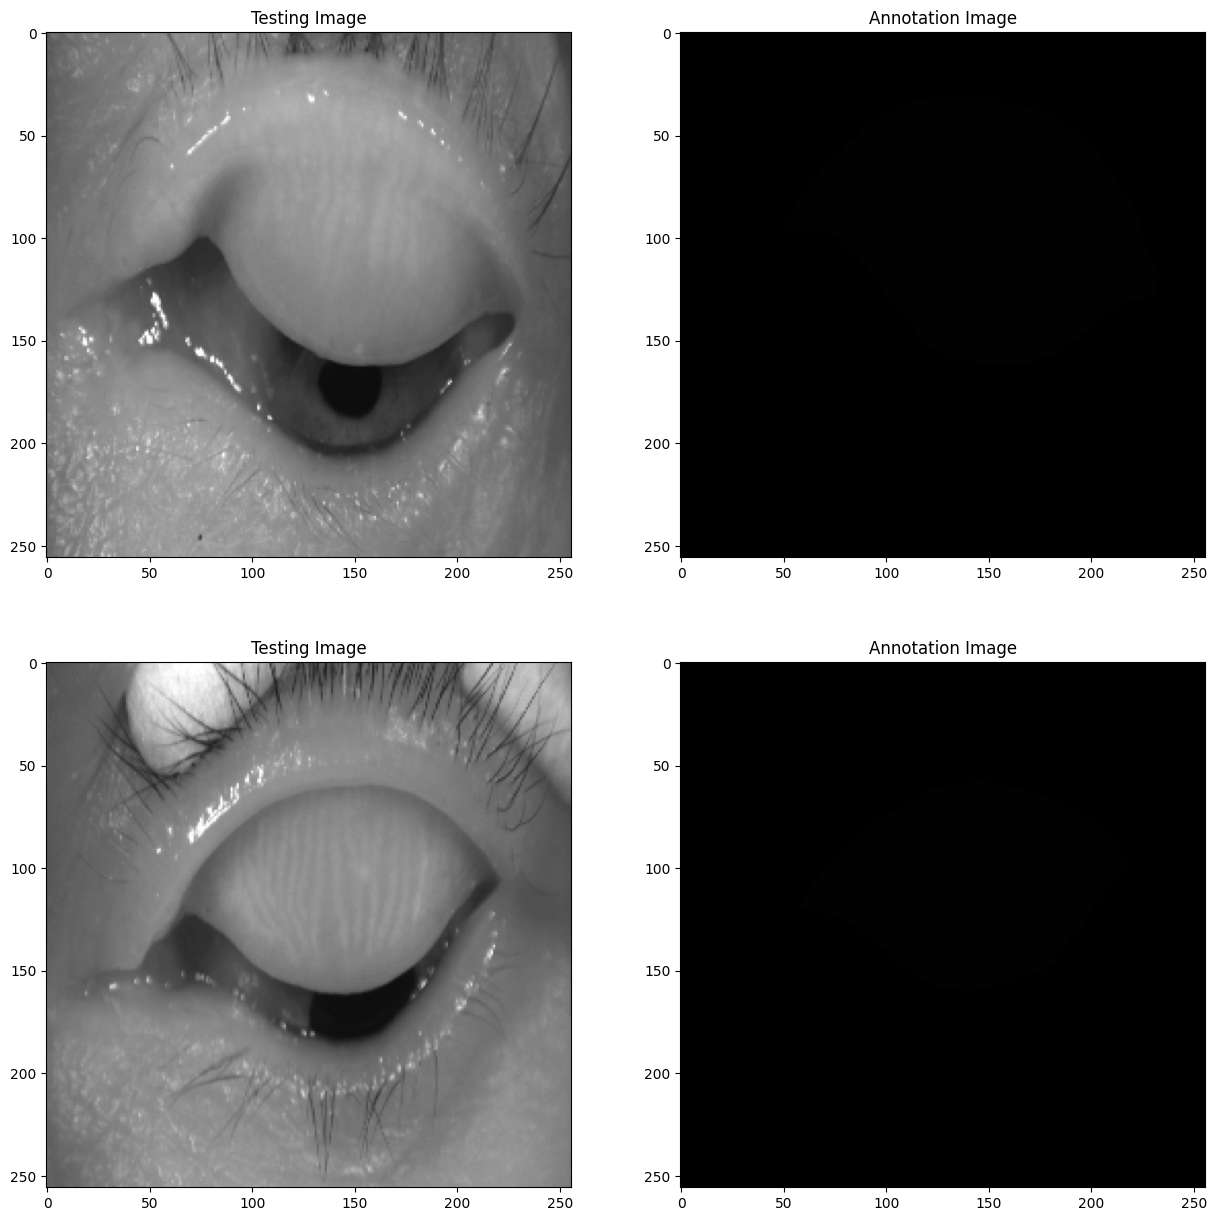

In [ ]:
plt.figure(figsize=(15,15))
for i in range(1, 4, 2):
  plt.subplot(2, 2, i)
  plt.imshow(data_train_arr[i], cmap='gray', vmin=0, vmax=255)
  plt.title('Testing Image')
  plt.subplot(2, 2, i+1)
  plt.imshow(anotasi_train_arr[i], cmap='gray', vmin=0, vmax=255)
  plt.title('Annotation Image')
plt.show()

In [ ]:
def get_class(image_y):
  array = image_y.ravel()
  return np.unique(array)

In [ ]:
# get information from the dataset
print('image prepped train shape:', data_train_arr.shape)
print('annotations prepped train shape:', anotasi_train_arr.shape)
#print('image prepped test shape:', data_test_arr.shape)
#print('annotations prepped test shape:', anotasi_test_arr.shape)
print('data train:', len(data_train_arr))
#print('data test:', len(data_test_arr))

print('\n')
print("unique value of 'annotation'")
print("kind of class :", get_class(anotasi_train_arr[0]))
print("kind of class :", get_class(anotasi_train_arr[1]))
print("kind of class :", get_class(anotasi_train_arr[2]))
print("number of classes:", len(get_class(anotasi_train_arr[0])))

print('\n')
print("unique value of 'image'")
print("kind of class :\n", get_class(data_train_arr[0]))
print("number of classes:", len(get_class(data_train_arr[0])))

image prepped train shape: (417, 256, 256)
annotations prepped train shape: (417, 256, 256)
data train: 417


unique value of 'annotation'
kind of class : [0 1 2]
kind of class : [0 1 2]
kind of class : [0 1 2]
number of classes: 3


unique value of 'image'
kind of class :
 [ 22  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40
  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58
  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76
  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94
  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112
 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130
 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148
 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166
 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184
 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201

In [ ]:
# Data train
train_x_norm = np.expand_dims(data_train_arr, axis=3)
#train_x_norm = data_train_arr
train_y_norm = np.expand_dims(anotasi_train_arr, axis=3)
#train_y_norm = anotasi_train_arr

# Data test
#test_x_norm = np.expand_dims(data_test_arr, axis=3)
#test_x_norm = data_test_arr
#test_y_norm = np.expand_dims(anotasi_test_arr, axis=3)
#test_y_norm = anotasi_test_arr

# Example
# train_x_norm2 = np.expand_dims(normalize(np.array(data_train_arr), axis=1), axis=3)
# train_y_norm2 = np.expand_dims(normalize(np.array(anotasi_train_arr), axis=1), axis=3)

In [ ]:
# after normalization data
print('Train images shape:', train_x_norm.shape)
print('Train annots shape:', train_y_norm.shape)
#print('Test images shape:', test_x_norm.shape)
#print('Test annots shape:', test_y_norm.shape)

Train images shape: (417, 256, 256, 1)
Train annots shape: (417, 256, 256, 1)


In [ ]:
# split orginal data -> train & test data
random_state = 50

trainn_x, test_x, trainn_y, test_y = train_test_split(train_x_norm, train_y_norm, test_size=0.2, random_state=random_state)
print('Train images shape:', trainn_x.shape)
print('Test images shape:', test_x.shape)
print('Train annots shape:', trainn_y.shape)
print('test annots shape:', test_y.shape)

Train images shape: (333, 256, 256, 1)
Test images shape: (84, 256, 256, 1)
Train annots shape: (333, 256, 256, 1)
test annots shape: (84, 256, 256, 1)


In [ ]:
# split train data -> train & validation data
train_x, val_x, train_y, val_y = train_test_split(trainn_x, trainn_y, test_size=0.1, random_state=random_state)
print('Train images shape:', train_x.shape)
print('Valid images shape:', val_x.shape)
print('Train annots shape:', train_y.shape)
print('Valid annots shape:', val_y.shape)

Train images shape: (299, 256, 256, 1)
Valid images shape: (34, 256, 256, 1)
Train annots shape: (299, 256, 256, 1)
Valid annots shape: (34, 256, 256, 1)


In [ ]:

# num of classes
n_classes = 3

train_y[train_y > 2] = 0
val_y[val_y > 2] = 0
test_y[test_y > 2] = 0

# One Hot Encoding Train Data Annotation
train_y_cat = keras.utils.to_categorical(train_y, num_classes=n_classes)

# One Hot Encoding Val Data Annotation
val_y_cat = keras.utils.to_categorical(val_y, num_classes=n_classes)

# One Hot Encoding Test Data Annotation
test_y_cat = keras.utils.to_categorical(test_y, num_classes=n_classes)

<Figure size 1500x500 with 0 Axes>

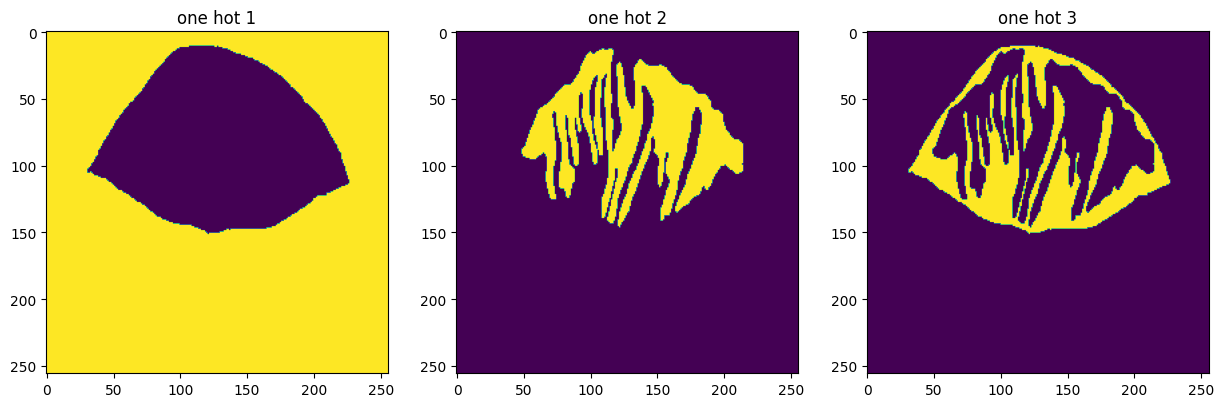

In [ ]:
#Plot one hot encoding
fig = plt.figure(figsize = (15,5))
fig2 = plt.figure(figsize = (15,5))

for index in range(1, 4):
    ax = fig2.add_subplot(1,3, index)
    ax.set_title("one hot {}".format(index))
    ax.imshow(train_y_cat[0][:,:,index-1])

plt.show()

In [ ]:
# after encode annotations dataset
print('Class values in the dataset are:', get_class(train_y[0]))
print('Train images shape', train_x.shape)
print('Train labels shape', train_y_cat.shape)

print('\nClass values in the dataset are:', get_class(val_y[0]))
print('Validation images shape', val_x.shape)
print('Validation labels shape', val_y_cat.shape)

print('\nClass values in the dataset are:', get_class(test_y[0]))
print('Test images shape', test_x.shape)
print('Test labels shape', test_y_cat.shape)

Class values in the dataset are: [0 1 2]
Train images shape (299, 256, 256, 1)
Train labels shape (299, 256, 256, 3)

Class values in the dataset are: [0 1 2]
Validation images shape (34, 256, 256, 1)
Validation labels shape (34, 256, 256, 3)

Class values in the dataset are: [0 1 2]
Test images shape (84, 256, 256, 1)
Test labels shape (84, 256, 256, 3)


In [ ]:
def UNet(image_size, ch_in=1, ch_out=3):

    inputs = Input(shape=(*image_size, ch_in), name='input')

    # The Contraction Path
    # Blok 1
    conv1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    batch1 = BatchNormalization()(conv1)
    conv1 = Conv2D(64, 3, activation='relu', padding='same')(batch1)
    pool1 = MaxPooling2D(pool_size=(2,2))(conv1)

    # Blok 2
    conv2 = Conv2D(128, 3, activation='relu', padding='same')(pool1)
    batch2 = BatchNormalization()(conv2)
    conv2 = Conv2D(128, 3, activation='relu', padding='same')(batch2)
    pool2 = MaxPooling2D(pool_size=(2,2))(conv2)

    # Blok 3
    conv3 = Conv2D(256, 3, activation='relu', padding='same')(pool2)
    batch3 = BatchNormalization()(conv3)
    conv3 = Conv2D(256, 3, activation='relu', padding='same')(batch3)
    pool3 = MaxPooling2D(pool_size=(2,2))(conv3)

    # Blok 4
    conv4 = Conv2D(512, 3, activation='relu', padding='same')(pool3)
    batch4 = BatchNormalization()(conv4)
    conv4 = Conv2D(512, 3, activation='relu', padding='same')(batch4)
    pool4 = MaxPooling2D(pool_size=(2,2))(conv4)

    # The Bottleneck Path
    # Blok 5
    conv5 = Conv2D(1024, 3, activation='relu', padding='same')(pool4)
    conv5 = Conv2D(1024, 3, activation='relu', padding='same')(conv5)
    dropout = tf.keras.layers.Dropout(0.5)(conv5)

    # The Expansion Path
    # Blok 6
    up6 = Conv2D(512, 2, activation='relu', padding='same')(UpSampling2D(size=(2,2))(dropout))
    merge6 = concatenate([conv4, up6], axis=3)
    conv6 = Conv2D(512, 3, activation='relu', padding='same')(merge6)
    batch6 = BatchNormalization()(conv6)
    conv6 = Conv2D(512, 3, activation='relu', padding='same')(batch6)

    # Blok 7
    up7 = Conv2D(256, 2, activation='relu', padding='same')(UpSampling2D(size=(2,2))(conv6))
    merge7 = concatenate([conv3, up7], axis=3)
    conv7 = Conv2D(256, 3, activation='relu', padding='same')(merge7)
    batch7 = BatchNormalization()(conv7)
    conv7 = Conv2D(256, 3, activation='relu', padding='same')(batch7)

    # Blok 8
    up8 = Conv2D(128, 2, activation='relu', padding='same')(UpSampling2D(size=(2,2))(conv7))
    merge8 = concatenate([conv2, up8], axis=3)
    conv8 = Conv2D(128, 3, activation='relu', padding='same')(merge8)
    batch8 = BatchNormalization()(conv8)
    conv8 = Conv2D(128, 3, activation='relu', padding='same')(batch8)

    # Blok 9
    up9 = Conv2D(64, 2, activation='relu', padding='same')(UpSampling2D(size=(2,2))(conv8))
    merge9 = concatenate([conv1, up9], axis=3)
    conv9 = Conv2D(64, 3, activation='relu', padding='same')(merge9)
    batch9 = BatchNormalization()(conv9)
    conv9 = Conv2D(64, 3, activation='relu', padding='same')(batch9)

    # jumlah unit = jumlah class = pada kasus ini 3
    unit = 3
    conv10 = Conv2D(unit, 1, activation='relu')(conv9)
    conv10 = Conv2D(unit, 1, activation='softmax')(conv10)

    outputs = conv10

    model = Model(inputs, outputs)

    return model

In [ ]:
model = UNet(image_size=(256,256))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)        │ (None, 256, 256, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 256, 256, 64)   │            640 │ input[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 256, 256, 64)   │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 256, 256, 64)   │         36,928 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 128, 128, 64)   │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 128, 128, 128)  │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 128, 128, 128)  │            512 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 128, 128, 128)  │        147,584 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 64, 64, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 64, 64, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 64, 64, 256)    │          1,024 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 64, 64, 256)    │        590,080 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 32, 32, 256)    │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 32, 32, 512)    │      1,180,160 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 32, 32, 512)    │          2,048 │ conv2d_6[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 32, 32, 512)    │      2,359,808 │ batch_normalization_3… │
├──────────────────────

 Total params: 31,038,415 (118.40 MB)

 Trainable params: 31,034,575 (118.39 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [ ]:
#Cek running time
import timeit
start = timeit.default_timer()

# from re import VERBOSE
# Train training ke-
iter = 2
batch_size = 16
epoch = 100
lr = 0.0001


# Checkpoint
MODEL_DIRECTORY = GDRIVE_PATH + "Meibomian/"
MODEL_NAME = f'model_fix-{iter}({lr})_{random_state}.keras'
MODEL_PATH = os.path.join(MODEL_DIRECTORY, MODEL_NAME)
model_checkpoint = keras.callbacks.ModelCheckpoint(filepath=MODEL_PATH,
                                                            monitor='val_accuracy',
                                                            mode='max',
                                                            save_best_only=True)

# Early Stopping
#early_stopping = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, mode='max', min_delta=0.0001, verbose = 1, restore_best_weights = True)

opt = Adam(learning_rate=lr)
model.compile(optimizer=opt, loss=keras.losses.categorical_crossentropy, metrics=['accuracy',tf.keras.metrics.Precision(),
                                                                                  tf.keras.metrics.Recall(),tf.keras.metrics.OneHotMeanIoU(num_classes=3)])

# Train model
history = model.fit(train_x, train_y_cat,
                    validation_data=(val_x, val_y_cat),
                    epochs=epoch,
                    batch_size=batch_size,
                    callbacks=[model_checkpoint])
'''history = model.fit(train_x, train_y_cat,
                    validation_data=(val_x, val_y_cat),
                    epochs=epoch,
                    batch_size=batch_size,
                    callbacks=[model_checkpoint, early_stopping])'''
stop = timeit.default_timer()
print('\nTime: ', stop - start)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 297s 11s/step - accuracy: 0.6108 - loss: 0.9233 - one_hot_mean_io_u: 0.2957 - precision: 0.7892 - recall: 0.2427 - val_accuracy: 0.2569 - val_loss: 1.0671 - val_one_hot_mean_io_u: 0.1029 - val_precision: 0.3782 - val_recall: 6.7587e-04
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8477 - loss: 0.5001 - one_hot_mean_io_u: 0.4984 - precision: 0.9386 - recall: 0.7545 - val_accuracy: 0.2631 - val_loss: 1.0546 - val_one_hot_mean_io_u: 0.1054 - val_precision: 0.9728 - val_recall: 0.0244
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8735 - loss: 0.3515 - one_hot_mean_io_u: 0.5314 - precision: 0.9161 - recall: 0.8358 - val_accuracy: 0.3236 - val_loss: 1.1019 - val_one_hot_mean_io_u: 0.1243 - val_precision: 0.6415 - val_recall: 0.0777
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9016 - loss: 0.2688 - one_hot_mean_io_u: 0.6057 - precision: 0.9187 - recall: 0.8851 - val_accuracy: 0.5018 - val_loss: 0.

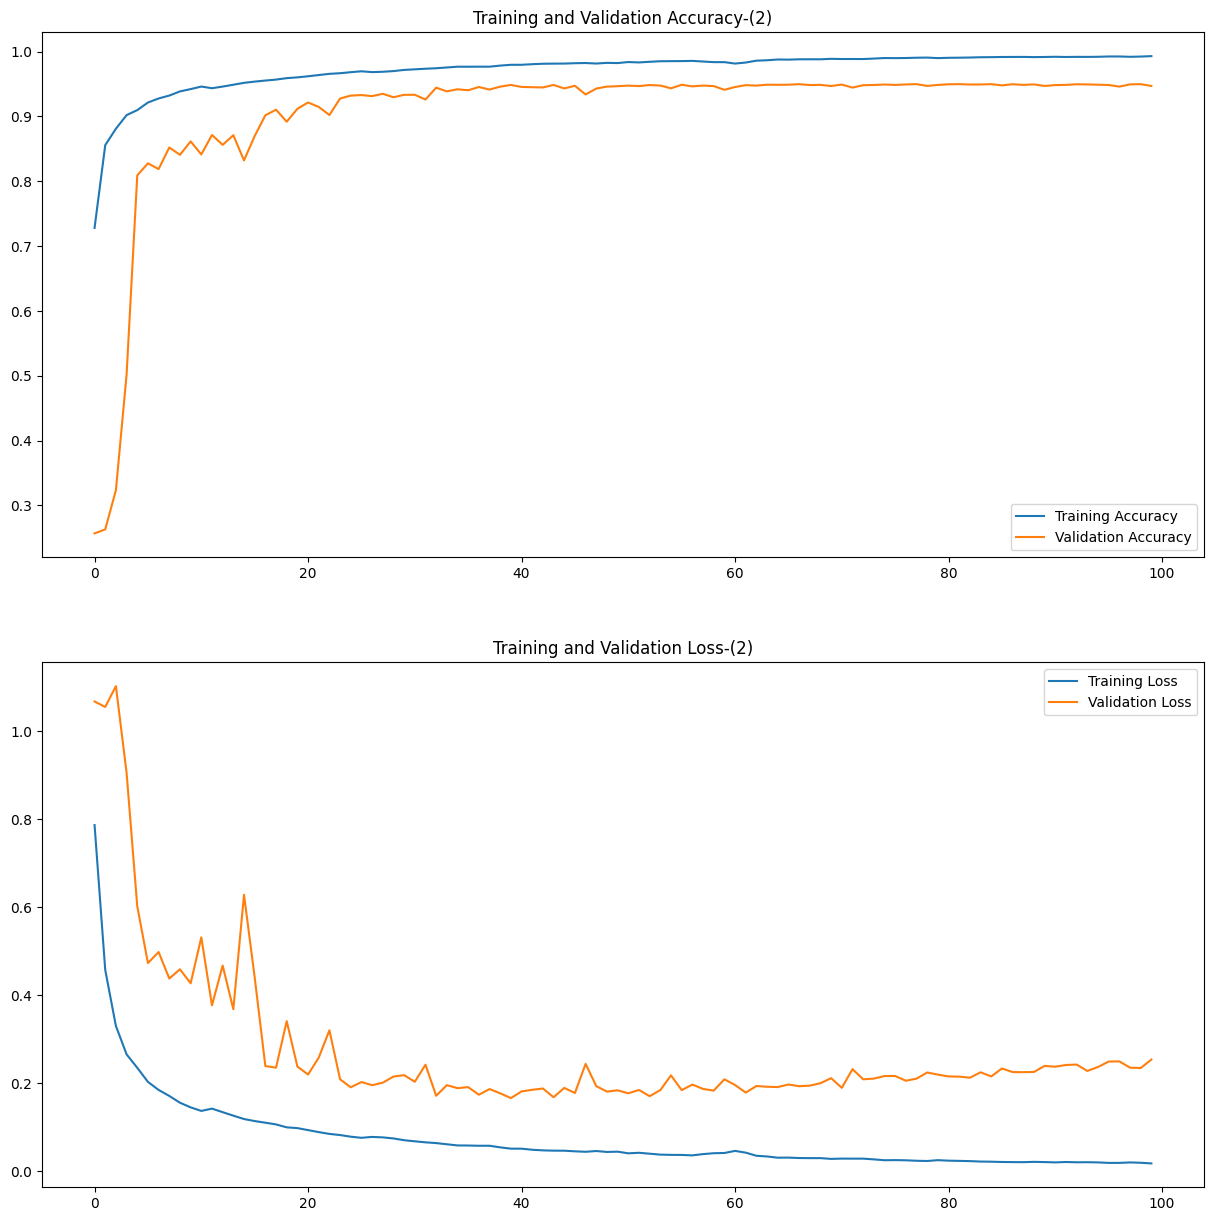

In [ ]:
# Plot training and validation
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = history.epoch

plt.figure(figsize=(15,15))
plt.subplot(2,1,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='best')
plt.title(f'Training and Validation Accuracy-({iter})')

plt.subplot(2,1,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='best')
plt.title(f'Training and Validation Loss-({iter})')

# save figure
# PATH_FIGURE = "Skripsi/Model/"
# dir_name = os.path.join(GDRIVE_PATH, PATH_FIGURE)
# plt.rcParams["savefig.directory"] = os.chdir(os.path.dirname(dir_name))
# print('saving figure to:')
# plt.savefig(f"Training and validation-{iter}.png")

plt.show()

In [ ]:
# View the models stored in the model directory
MODEL_DIRECTORY = GDRIVE_PATH + "Meibomian/"
MODEL_LISTDIR = os.listdir(MODEL_DIRECTORY)
MODEL_LISTDIR

['Annotasi',
 'Image',
 'eye_segmen_0.png',
 'eye_segmen_1.png',
 'eye_segmen_2.png',
 'eye_segmen_3.png',
 'eye_segmen_4.png',
 'eye_segmen_5.png',
 'eye_segmen_6.png',
 'eye_segmen_7.png',
 'eye_segmen_8.png',
 'eye_segmen_9.png',
 'eye_segmen_10.png',
 'eye_segmen_11.png',
 'eye_segmen_12.png',
 'eye_segmen_13.png',
 'eye_segmen_14.png',
 'eye_segmen_15.png',
 'eye_segmen_16.png',
 'eye_segmen_17.png',
 'eye_segmen_18.png',
 'eye_segmen_19.png',
 'eye_segmen_20.png',
 'eye_segmen_21.png',
 'eye_segmen_22.png',
 'eye_segmen_23.png',
 'eye_segmen_24.png',
 'eye_segmen_25.png',
 'eye_segmen_26.png',
 'eye_segmen_27.png',
 'eye_segmen_28.png',
 'eye_segmen_29.png',
 'eye_segmen_30.png',
 'eye_segmen_31.png',
 'eye_segmen_32.png',
 'eye_segmen_33.png',
 'eye_segmen_34.png',
 'eye_segmen_35.png',
 'eye_segmen_36.png',
 'eye_segmen_37.png',
 'eye_segmen_38.png',
 'eye_segmen_39.png',
 'eye_segmen_40.png',
 'eye_segmen_41.png',
 'eye_segmen_42.png',
 'eye_segmen_43.png',
 'eye_segmen_44.png

In [ ]:
GDRIVE_PATH

'/content/drive/MyDrive/'

In [ ]:
# load the model and weight
# Get a list of model files with .keras or .h5 extension
model_files = [f for f in MODEL_LISTDIR if f.endswith(('.keras', '.h5'))]

# If no model files are found, print an error message
if not model_files:
    raise ValueError("No model files found in the directory. Please check the directory and file extensions.")

# Load the first model file found
LOADMODEL_PATH = os.path.join(MODEL_DIRECTORY, model_files[0])
load_model_seg = keras.models.load_model(LOADMODEL_PATH)
print('Loaded trained model at %s' %LOADMODEL_PATH)

Loaded trained model at /content/drive/MyDrive/Meibomian/model_fix-2(0.0001)_50.keras


In [ ]:
y_pred1=load_model_seg.predict(train_x)
y_pred_argmax1=np.argmax(y_pred1, axis=3)
y_pred_argmax1.shape

10/10 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step


(299, 256, 256)

In [ ]:
y_pred2=load_model_seg.predict(val_x)
y_pred_argmax2=np.argmax(y_pred2, axis=3)
y_pred_argmax2.shape

NameError: name 'load_model_seg' is not defined

In [ ]:
y_pred3=load_model_seg.predict(test_x)
y_pred_argmax3=np.argmax(y_pred3, axis=3)
y_pred_argmax3.shape

In [ ]:
score1 = load_model_seg.evaluate(train_x[:], train_y_cat[:], verbose=0)
print("Train loss:", score1[0])
print("Train accuracy:", score1[1])
print("Train precision:", score1[2])
print("Train recall:", score1[3])

score2 = load_model_seg.evaluate(val_x[:], val_y_cat[:], verbose=0)
print("\nVal loss:", score2[0])
print("Val accuracy:", score2[1])
print("Val precision:", score2[2])
print("Val recall:", score2[3])

score3 = load_model_seg.evaluate(test_x[:], test_y_cat[:], verbose=0)
print("\nTest loss:", score3[0])
print("Test accuracy:", score3[1])
print("Test precision:", score3[2])
print("Test recall:", score3[3])

In [ ]:
#Using built in keras function
from keras.metrics import MeanIoU
n_classes = 3
IOU_keras = MeanIoU(num_classes=n_classes)
IOU_keras.update_state(train_y[:,:,:,0], y_pred_argmax1)
print("\nOne Hot Mean IoU Train=", IOU_keras.result().numpy())

n_classes = 3
IOU_keras = MeanIoU(num_classes=n_classes)
IOU_keras.update_state(val_y[:,:,:,0], y_pred_argmax2)
print("One Hot Mean IoU Val=", IOU_keras.result().numpy())

n_classes = 3
IOU_keras = MeanIoU(num_classes=n_classes)
IOU_keras.update_state(test_y[:,:,:,0], y_pred_argmax3)
print("One Hot Mean IoU Test=", IOU_keras.result().numpy())

In [ ]:
import random

In [ ]:
n_classes=3
# give color annota img
def give_color_to_annota_img(annota_img):
  random_colors = []

  for i in range(5000):
    random.seed(i)
    randColor = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
    random_colors.append(randColor)

  annota_img_zeros = np.zeros((256, 256, 3))
  for j in range(n_classes):
    annota_img_zeros[:, :, 0] += ((annota_img[:, :, 0] == j)*(random_colors[j][0])).astype('uint8')
    annota_img_zeros[:, :, 1] += ((annota_img[:, :, 0] == j)*(random_colors[j][1])).astype('uint8')
    annota_img_zeros[:, :, 2] += ((annota_img[:, :, 0] == j)*(random_colors[j][2])).astype('uint8')

  annota_img_zeros = cv2.cvtColor(np.array(annota_img_zeros, dtype=np.uint8), cv2.COLOR_BGR2RGB)
  return annota_img_zeros

# plot grayscale img
def plot_img(input_img, title='', iter=0):
  N_ch = input_img.shape[2]
  if N_ch == 1:
    plt.imshow(input_img[:,:,0], cmap='gray', vmin=0, vmax=255)
    plt.title(title)
  elif N_ch == 3:
    plt.imshow(input_img)
    plt.title(title)
  else:
    print('error image')
    return
  # set the spacing between subplots
  plt.subplots_adjust(bottom=0.1, top=0.5)

# invert encoding (to_categorical) to original data
def invert_from_cat(img_cat):
  inverted = tf.keras.backend.argmax(img_cat)
  inverted_1dims = np.expand_dims(inverted, axis=2)
  return inverted_1dims

# preprocessing to predict
def prepare(filename):
  IMAGE_CHANNEL = 1 # or 3
  IMG_SIZE = 256
  new_array = cv2.resize(filename, (IMG_SIZE, IMG_SIZE))
  return new_array.reshape(-1, IMG_SIZE, IMG_SIZE, IMAGE_CHANNEL)

# IoU of Each Class
def get_IoU_of_class(annota_img, pred_img):
  from keras.metrics import MeanIoU
  val,sum3 = 0,0
  IoU_arr = []
  IoU_keras = MeanIoU(num_classes=n_classes)
  IoU_keras.update_state(annota_img, pred_img)
  values = np.array(IoU_keras.get_weights()).reshape(n_classes, n_classes)
  print("IoU of Each Class:")
  for i in range (n_classes):
    val = values[i,i]
    sum1 = 0
    for j in range(n_classes):
        sum1 = values[i,j] + sum1
    sum2 = 0
    for k in range(n_classes):
        if k != i:
            sum2 = values[k, i] + sum2
        else:
            continue
    sum3 = sum1 + sum2
    IoU_arr.append(val/sum3)
    print(f"IoU Class {i}: {val/sum3*100:.2f}%")
  print(f"Mean IoU: {IoU_keras.result().numpy()*100:.2f}%")
  print("conf matrix:\n", values)


  plt.figure(figsize=(8, 5))
  plt.bar(np.arange(0, len(IoU_arr)), IoU_arr)
  plt.xticks(np.arange(0, len(IoU_arr)))
  plt.ylabel("IoU")
  plt.xlabel("Class")
  plt.title("IoU of Each Class")

# Function to predict
# input: 1 image from test_x & test_y_cat
def predict_annotation(img_x, img_y, iter=0):
  # inverse from normalize data
  grayscale_img = img_x*255*255

  # predict image
  prediction = load_model_seg.predict([prepare(img_x)])
  prediction_reshape = prediction.reshape((256, 256, 3)) # test_y_cat[0].shape

  # invert predict from categorical
  pred_invert = invert_from_cat(prediction_reshape)
  annota_img = invert_from_cat(img_y)

  # give color to pred_invert image
  colored_annota_img = give_color_to_annota_img(annota_img)
  colored_pred = give_color_to_annota_img(pred_invert)

  # masked image
  grayscale_img3ch = np.zeros((256, 256, 3))
  grayscale_img3ch = np.expand_dims(grayscale_img3ch, axis=3)

  #grayscale_img3ch[:,:,0] += grayscale_img
  #grayscale_img3ch[:,:,1] += grayscale_img
  #grayscale_img3ch[:,:,2] += grayscale_img
  #grayscale_img3ch2 = grayscale_img3ch.reshape(grayscale_img3ch.shape[0],grayscale_img3ch.shape[1], grayscale_img3ch.shape[2])
  #masked_image = cv2.addWeighted(np.array(grayscale_img3ch2, dtype=np.uint8), 0.5, np.array(colored_pred, dtype=np.uint8), 0.5, 0)

  # plot image
  #img_arr = [grayscale_img, annota_img, colored_annota_img, pred_invert, colored_pred, masked_image]
  #img_arr = [grayscale_img, annota_img, colored_annota_img, pred_invert, colored_pred]
  img_arr = [grayscale_img, colored_annota_img, colored_pred]
  #title_arr = ['Testing Image', 'Annotation Image', 'Annotation Image Colored', 'Prediction Annotation', 'Prediction Annotation Colored', 'Masked Image']
  title_arr = ['Testing Image', 'Annotation Image', 'Prediction']
  huruf = ['(A)', '(B)', '(C)']
  plt.figure(figsize=(20,20))
  for i in range(len(img_arr)):
    #plt.subplot(len(img_arr)/1, len(img_arr)/1, i+1)
    #plt.subplot(len(img_arr), len(img_arr), i+1)
    plt.subplot(int(len(img_arr)/3), int(len(img_arr)/1), i+1)
    plot_img(img_arr[i], huruf[i])

  # save figure
  # PATH_FIGURE = "Skripsi/Model/"
  # dir_name = os.path.join(GDRIVE_PATH, PATH_FIGURE)
  # plt.rcParams["savefig.directory"] = os.chdir(os.path.dirname(dir_name))
  # plt.savefig(f"Prediction-{iter}.png")
  # print(f'saving figure to: {dir_name}\n')

  # IoU of Each Class
  get_IoU_of_class(annota_img, pred_invert)

  # plot figure
  plt.tight_layout()
  plt.show()

# testing the function
# predict_annotation(test_x[15], test_y_cat[15], 3)

In [ ]:
y_cat = np.concatenate([train_y_cat, val_y_cat, test_y_cat])

In [ ]:
y_norm = train_y_norm
y_norm[y_norm > 2] = 0

y_annot = keras.utils.to_categorical(y_norm, 3)

In [ ]:
MODEL_DIRECTORY = GDRIVE_PATH + "Meibomian/"
MODEL_LISTDIR = os.listdir(MODEL_DIRECTORY)
MODEL_LISTDIR

In [ ]:
# load the model and weight
# Get a list of model files with .keras or .h5 extension
model_files = [f for f in MODEL_LISTDIR if f.endswith(('.keras', '.h5'))]

# If no model files are found, print an error message
if not model_files:
    raise ValueError("No model files found in the directory. Please check the directory and file extensions.")

# Load the first model file found
LOADMODEL_PATH = os.path.join(MODEL_DIRECTORY, model_files[0])
load_model_seg = keras.models.load_model(LOADMODEL_PATH)
print('Loaded trained model at %s' %LOADMODEL_PATH)

Loaded trained model at /content/drive/MyDrive/Meibomian/model_fix-2(0.0001)_50.keras


In [ ]:
def area_eyelid(contours_eyelid):
  areas = []
  for cnt in contours_eyelid:
      cont_area = cv2.contourArea(cnt)
      areas.append(cont_area)
  return max(areas)

In [ ]:
def area_mg(contours_mg):
  areas = []
  for cnt in contours_mg:
      cont_area = cv2.contourArea(cnt)
      areas.append(cont_area)
  return sum(areas)

In [ ]:
def img_pred(img_x):
  prediction = load_model_seg.predict([prepare(img_x)])
  prediction_reshape = prediction.reshape((256, 256, 3))
  prediction_resize = cv2.resize(prediction_reshape, (224,224), interpolation=cv2.INTER_NEAREST)
  return prediction_resize

y_pred = []
for i in range(train_x_norm.shape[0]):
  y_pred.append(img_pred(train_x_norm[i]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━

In [ ]:
def save_pred(img_x):
  prediction = load_model_seg.predict([prepare(img_x)])
  prediction_reshape = prediction.reshape((256, 256, 3))

  fig = plt.figure(frameon=False)
  fig.set_size_inches(1,1)

  ax = plt.Axes(fig, [0., 0., 1., 1.])
  ax.set_axis_off()
  fig.add_axes(ax)

  ax.imshow(prediction_reshape, aspect='auto')
  fig.savefig(GDRIVE_PATH + f'Meibomian/Segmen/eye_segmen_{i}.png', dpi=224)

for i in range(train_x_norm.shape[0]):
  save_pred(train_x_norm[i])

In [ ]:
def save_pred_mil(img_x):
  prediction = load_model_seg.predict([prepare(img_x)])
  prediction_reshape = prediction.reshape((256, 256, 3))

  fig = plt.figure(frameon=False)
  fig.set_size_inches(1,1)

  ax = plt.Axes(fig, [0., 0., 1., 1.])
  ax.set_axis_off()
  fig.add_axes(ax)

  ax.imshow(prediction_reshape, aspect='auto')
  fig.savefig(GDRIVE_PATH + f'Meibomian/Eyelid/eyelid_segmen_{i}.png', dpi=224)

  ax.imshow(prediction_reshape, aspect='auto')
  fig.savefig(GDRIVE_PATH + f'Meibomian/MG/mg_segmen_{i}.png', dpi=224)

for i in range(train_x_norm.shape[0]):
  save_pred_mil(train_x_norm[i])

In [ ]:
# Label Image Segmented

dataset_seg = pd.DataFrame()
scale = []

for i in range(417):
  img_eyelid = cv2.imread(GDRIVE_PATH + f'Meibomian/Eyelid/eyelid_segmen_{i}.png')
  img_gray_eye = cv2.cvtColor(img_eyelid, cv2.COLOR_BGR2GRAY)
  gray_inverted_eye = cv2.bitwise_not(img_gray_eye)
  ret, thresh_eye = cv2.threshold(gray_inverted_eye, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
  contours_eyelid, hierarchy = cv2.findContours(thresh_eye, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

  img_mg = cv2.imread(GDRIVE_PATH + f'Meibomian/MG/mg_segmen_{i}.png')
  # median_img = cv2.medianBlur(img_mg, 3)
  img_gray_mg = cv2.cvtColor(img_mg, cv2.COLOR_BGR2GRAY)
  ret, thresh_mg = cv2.threshold(img_gray_mg, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
  contours_mg, hierarchy = cv2.findContours(thresh_mg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

  meiboscore = (area_eyelid(contours_eyelid) - area_mg(contours_mg)) / area_eyelid(contours_eyelid) * 100
  if meiboscore <= (1/4 * 100):
    scale.append('meiboscore 0')
  elif meiboscore <= (2/4 * 100):
    scale.append('meiboscore 1')
  elif meiboscore <= (3/4 * 100):
    scale.append('meiboscore 2')
  else:
    scale.append('meiboscore 3')

image = [cv2.resize(cv2.imread(GDRIVE_PATH + f'Meibomian/Segmen/eye_segmen_{i}.png'), (224,224), interpolation=cv2.INTER_NEAREST) for i in range(len(scale))]

dataset_seg['Image'] = image
dataset_seg['meiboscore'] = scale

dataset_seg.head()

In [ ]:
def save_dataset_pred(image):
  for i,j in enumerate(dataset_seg['meiboscore']):
    fig=plt.figure(frameon=False)
    fig.set_size_inches(1,1)

    ax = plt.Axes(fig, [0., 0., 1., 1.])
    ax.set_axis_off()
    fig.add_axes(ax)

    if j == 'meiboscore 0':
      ax.imshow(image[i], aspect='auto')
      fig.savefig(GDRIVE_PATH + f'Meibomian/Prediction/Skala0/Skala0_eye_{i}.png', dpi=224)
    elif j == 'meiboscore 1':
      ax.imshow(image[i], aspect='auto')
      fig.savefig(GDRIVE_PATH + f'Meibomian/Prediction/Skala1/Skala1_eye_{i}.png', dpi=224)
    elif j == 'meiboscore 2':
      ax.imshow(image[i], aspect='auto')
      fig.savefig(GDRIVE_PATH + f'Meibomian/Prediction/Skala2/Skala2_eye_{i}.png', dpi=224)
    else:
      ax.imshow(image[i], aspect='auto')
      fig.savefig(GDRIVE_PATH + f'Meibomian/Prediction/Skala3/Skala3_eye_{i}.png', dpi=224)

save_dataset_pred(y_pred)

In [ ]:
paths = ['/content/drive/MyDrive/Meibomian/Prediction/Skala0', '/content/drive/MyDrive/Meibomian/Prediction/Skala1',
'/content/drive/MyDrive/Meibomian/Prediction/Skala2', '/content/drive/MyDrive/Meibomian/Prediction/Skala3']
labels = ['meibosore 0', 'meiboscore 1','meiboscore 2', 'meiboscore 3']
dfs = []

for i in range(0, len(paths)):
  files = []
  for p in os.listdir(paths[i]):
    if os.path.isfile(os.path.join(paths[i],p)):
      t = [paths[i]+"/"+p, labels[i]]
      files.append(t)
  df = pd.DataFrame(files, columns=['img_path', 'meiboscore'])
  dfs.append(df)
dfrop = pd.concat(dfs, axis=0)
df_seg = dfrop.sample(frac=1)

In [ ]:
df_seg['meiboscore'].value_counts()

In [ ]:
def squeezenet(input_shape, n_classes):
    def fire(m, fs, fe):
        s = Conv2D(fs, 1, activation='relu')(m)
        e1 = Conv2D(fe, 1, activation='relu')(s)
        e3 = Conv2D(fe, 3, padding='same', activation='relu')(s)
        output = Concatenate()([e1, e3])
        return output

    input = Input(input_shape)

    m = Conv2D(96, 7, strides=2, padding='same', activation='relu')(input)
    m = MaxPooling2D(3, strides=2, padding='same')(m)

    m = fire(m, 16, 64)
    m = fire(m, 16, 64)
    m = fire(m, 32, 128)
    m = MaxPooling2D(3, strides=2, padding='same')(m)

    m = fire(m,64,256)
    m = Conv2D(n_classes, 1)(m)
    m = GlobalAvgPool2D()(m)

    output = Activation('softmax')(m)

    model = Model(input, output)
    return model

In [ ]:
import time
from sklearn.metrics import roc_curve, auc
from random import randint
import os
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAvgPool2D, Activation, Concatenate
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

acc_score = []
loss_score = []
auc_score = []
times = []
rand_state = []
lr = 0.001
batch_size = 32
img_height = 224
img_width = 224
input_shape = (img_height, img_width, 3)
n_classes = 1

for i in range(1, 6):
  random_state = randint(0,100)
  print(f"Random State: {random_state}")
  rand_state.append(random_state)

  now = time.time()
  train_df, test_df = train_test_split(df_seg, test_size=0.2, random_state=random_state)

  train_df = train_df[train_df['meiboscore'].isin(labels)]
  test_df = test_df[test_df['meiboscore'].isin(labels)]

  train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input, validation_split=0.1)

  test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input)

  train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='img_path',
    y_col='meiboscore',
    batch_size=32,
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=False,
    subset='training'
  )

  val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='img_path',
    y_col='meiboscore',
    batch_size=32,
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=True,
    subset='validation'
  )

  test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='img_path',
    y_col='meiboscore',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=False
  )

  model = squeezenet(input_shape, n_classes)

  MODEL_DIRECTORY = GDRIVE_PATH + "Meibomian/ModelHasil/"
  MODEL_NAME = f'model_squeezenet-{i}({lr}).keras'
  MODEL_PATH = os.path.join(MODEL_DIRECTORY, MODEL_NAME)
  model_checkpoint = keras.callbacks.ModelCheckpoint(filepath=MODEL_PATH,
                                                     monitor='val_accuracy',
                                                     mode='max',
                                                     save_best_only=True)
  # early_stopping = keras.callbacks.EarlyStopping(monitor='val_accuracy',
  #                                                patience=4,
  #                                                mode='max')
  model.compile(optimizer=Adam(learning_rate=lr),
              loss=keras.losses.categorical_crossentropy,
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()])

  history = model.fit(train_images, validation_data=val_images, epochs=30,
                      callbacks=[model_checkpoint])

  print(f"Time: {time.time() - now}")

  MODEL_DIRECTORY = GDRIVE_PATH + "Meibomian/ModelHasil/"
  MODEL_LISTDIR = os.listdir(MODEL_DIRECTORY)
  LOADMODEL_PATH = os.path.join(MODEL_DIRECTORY, MODEL_LISTDIR[i-1])
  load_model = keras.models.load_model(LOADMODEL_PATH)
  then = time.time()
  test_score = load_model.evaluate(test_images, verbose=0)
  times.append(np.round(time.time() - then, 4))
  acc_score.append(np.round(test_score[1] * 100,2))
  loss_score.append(np.round(test_score[0],4))
  auc_score.append(np.round(test_score[4],4))

  score1 = load_model.evaluate(train_images, verbose=0)
  score2 = load_model.evaluate(val_images, verbose=0)

  print(f"Train loss: {score1[0]}")
  print(f"Val loss: {score2[0]}")

  print(f"\nTrain accuracy: {np.round(score1[1] * 100,2)}%")
  print(f"Val accuracy: {np.round(score2[1] * 100,2)}%")

  print(f"\nTrain AUC: {np.round(score1[4])}")
  print(f"Val AUC: {np.round(score2[4])}")

  # print(f"\nTrain precision: {np.round(score1[2] * 100,2)}%")
  # print(f"Val precision: {np.round(score2[2] * 100,2)}%")

  # print(f"\nTrain recall: {np.round(score1[3] * 100,2)}%")
  # print(f"Val recall: {np.round(score2[3] * 100,2)}%")

  # Plot training and validation
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs_range = history.epoch

  plt.figure(figsize=(15,15))
  plt.subplot(2,1,1)
  plt.plot(epochs_range, acc, label='Training Accuracy')
  plt.plot(epochs_range, val_acc, label='Validation Accuracy')
  plt.legend(loc='best')
  plt.title(f'Training and Validation Accuracy-({i})')

  plt.subplot(2,1,2)
  plt.plot(epochs_range, loss, label='Training Loss')
  plt.plot(epochs_range, val_loss, label='Validation Loss')
  plt.legend(loc='best')
  plt.title(f'Training and Validation Loss-({i})')

  # save figure
  PATH_FIGURE = "Meibomian/Plot Model (val 0.1)/"
  dir_name = os.path.join(GDRIVE_PATH, PATH_FIGURE)
  print('saving figure to:')
  plt.savefig(dir_name + f"Training and validation Squeezenet-{i}.png")

  plt.show()

print(f"Rata-rata Accuracy : {np.round(np.mean(acc_score), 2)}%")
print(f"Rata-rata Loss : {np.round(np.mean(loss_score),4)}")
print(f"Rata-rata AUC : {np.mean(auc_score)}")

In [ ]:
for i,m in enumerate(rand_state):
  train_df, test_df = train_test_split(df_seg, test_size=0.2, random_state=m)

  train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input, validation_split=0.1)

  test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input)

  train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='img_path',
    y_col='meiboscore',
    batch_size=32,
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=False,
    subset='training'
  )

  val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='img_path',
    y_col='meiboscore',
    batch_size=32,
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=True,
    subset='validation'
  )

  test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='img_path',
    y_col='meiboscore',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=False
  )

  MODEL_DIRECTORY = GDRIVE_PATH + "Meibomian/ModelHasil/"
  MODEL_LISTDIR = os.listdir(MODEL_DIRECTORY)
  LOADMODEL_PATH = os.path.join(MODEL_DIRECTORY, MODEL_LISTDIR[i])
  load_model = keras.models.load_model(LOADMODEL_PATH)

  y_pred = load_model.predict(test_images)
  num_classes = y_pred.shape[1]
  y_true = test_images.classes
  y_true = keras.utils.to_categorical(y_true)

  # Menghitung false positive rate (fpr) dan true positive rate (tpr) menggunakan roc_curve
  fpr = dict()
  tpr = dict()
  roc_auc = dict()

  for j in range(num_classes):
    fpr[j], tpr[j], _ = roc_curve(y_true[:, j], y_pred[:, j])
    roc_auc[j] = auc(fpr[j], tpr[j])

  plt.figure()

  for k in range(num_classes):
    plt.plot(fpr[k], tpr[k], label=f'ROC curve meiboscore {k} (AUC = %0.2f)' % roc_auc[k])

  plt.plot([0, 1], [0, 1], 'k--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic')
  plt.legend(loc="lower right")
  plt.savefig(GDRIVE_PATH + f'Meibomian/ROC/roc_{i+1}.png', bbox_inches = 'tight')

  plt.show()